In [3]:
%pip install accelerate datasets evaluate rouge_score bert_score sacrebleu -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install transformers==4.45.2 trl==0.11.3 -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
# %%
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from trl import DPOTrainer, DPOConfig
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import evaluate

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# %%
# --- 2. Configuration ---
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # use GPU 1 only
MODEL_NAME = "distilgpt2"
DATASET_NAME = "HumanLLMs/Human-Like-DPO-Dataset"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS = 1
LEARNING_RATE = 5e-6
MAX_LENGTH = 512
MAX_RESPONSE_LENGTH = 256
EXP_NAME = "dpo_distilgpt2" # Changed from ppo to dpo

BASE_DIR = f"runs/{EXP_NAME}"
CKPT_DIR = f"{BASE_DIR}/checkpoints"
LOG_DIR = f"{BASE_DIR}/logs"
PLOT_DIR = f"{BASE_DIR}/plots"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

In [7]:
# %%
# --- 3. Load Model & Data ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
dataset = load_dataset(DATASET_NAME, split="train").train_test_split(test_size=0.2)

# Subsetting for efficiency
train_dataset = dataset["train"].select(range(min(len(dataset["train"]), 2048)))
eval_dataset = dataset["test"].select(range(min(len(dataset["test"]), 512)))

In [8]:
# %%
# --- 4. Define Generative Metrics (Local) ---
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def compute_generative_metrics(model, tokenizer, test_data):
    model.eval()
    predictions = []
    references = []
    
    print(f"Generating responses for {len(test_data)} samples...")
    for example in test_data:
        prompt = example["prompt"]
        target = example["chosen"]
        
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=64, 
                pad_token_id=tokenizer.eos_token_id,
                do_sample=True,
                temperature=0.7,
                repetition_penalty=1.2,
                no_repeat_ngram_size=2
            )
        
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
        
        # --- CRITICAL FIX START ---
        # BERTScore crashes on empty strings. If pred_text is empty, use a placeholder.
        if not pred_text or pred_text.strip() == "":
            pred_text = "." 
        # --- CRITICAL FIX END ---
        
        predictions.append(pred_text)
        references.append(target)

    # Compute Scores
    bleu = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    rouge = rouge_metric.compute(predictions=predictions, references=references)
    
    # We add model_type="roberta-large" and use_fast_tokenizer=False to be extra safe
    bert = bertscore_metric.compute(
        predictions=predictions, 
        references=references, 
        lang="en", 
        model_type="roberta-large"
    )

    return {
        "bleu": bleu["score"],
        "rougeL": rouge["rougeL"],
        "bert_f1": np.mean(bert["f1"])
    }, predictions

In [9]:
# %%
def compute_metrics(eval_output):
    """Calculates Accuracy/F1 based on DPO rewards (Chosen vs Rejected)."""
    # predictions can sometimes be a tuple (rewards, logits, etc.) 
    # and might be flattened or 2D depending on the TRL version.
    preds = eval_output.predictions
    
    # If preds is a tuple, we usually want the first element (the rewards/logits)
    if isinstance(preds, tuple):
        preds = preds[0]
        
    # If the array is 1D, TRL has flattened the [chosen_rewards, rejected_rewards]
    # We need to reshape it back to (N, 2)
    if len(preds.shape) == 1:
        # TRL often concatenates them, so we split them in half
        half = len(preds) // 2
        rewards_chosen = preds[:half]
        rewards_rejected = preds[half:]
    else:
        # Standard (N, 2) case
        rewards_chosen = preds[:, 0]
        rewards_rejected = preds[:, 1]
    
    # Accuracy: % of times chosen reward > rejected reward
    predictions = (rewards_chosen > rewards_rejected).astype(int)
    labels = np.ones_like(predictions) # Ground truth is always 1
    
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )
    
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,   
        "reward_margin": (rewards_chosen - rewards_rejected).mean()
    }

In [10]:
training_args = DPOConfig(
    output_dir=CKPT_DIR,
    report_to="tensorboard", 
    logging_dir=LOG_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    evaluation_strategy="steps",
    eval_steps=20,
    logging_steps=10,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    remove_unused_columns=False,
    save_total_limit=2,
    # DPO specific arguments moved here from the trainer call
    beta=0.005,
    max_length=MAX_LENGTH,
    max_prompt_length=MAX_RESPONSE_LENGTH,
    max_steps=300,
    fp16=True if torch.cuda.is_available() else False,
    gradient_checkpointing=True, # Reduces VRAM usage for GPT-2
)

trainer = DPOTrainer(
    model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Tokenizing eval dataset: 100%|██████████| 512/512 [00:00<00:00, 706.47 examples/s]
max_steps is given, it will override any value given in num_train_epochs


In [11]:
# %%
# --- 7. Execution ---
print("Starting DPO training...")
trainer.train()

Starting DPO training...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Reward Margin,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/rejected,Logps/chosen,Logits/rejected,Logits/chosen
20,0.612000,0.579265,0.687500,0.814815,1.000000,0.687500,0.240084,0.061167,-0.182831,1.000000,0.243998,-583.012512,-676.661987,-65.090202,-67.665802
40,0.502600,0.471352,0.656250,0.792453,1.000000,0.656250,0.233536,0.065338,-0.449793,1.000000,0.515131,-636.404907,-675.827759,-66.543282,-68.589783
60,0.377400,0.365122,0.625000,0.769231,1.000000,0.625000,0.211032,0.008862,-0.836059,1.000000,0.844921,-713.658142,-687.122925,-67.743286,-69.341431
80,0.278500,0.260101,0.562500,0.720000,1.000000,0.562500,0.175157,-0.138418,-1.427560,1.000000,1.289141,-831.958252,-716.579102,-68.335007,-69.759865
100,0.208500,0.159199,0.562500,0.720000,1.000000,0.562500,0.157822,-0.431919,-2.405600,1.000000,1.973680,-1027.566284,-775.279297,-68.585014,-70.112648
120,0.080700,0.055338,0.656250,0.792453,1.000000,0.656250,0.689941,-1.316274,-4.964821,1.000000,3.648547,-1539.410400,-952.150208,-83.194328,-76.733261
140,0.018000,0.018002,0.593750,0.745098,1.000000,0.593750,0.200111,-1.505348,-6.940359,1.000000,5.435011,-1934.518066,-989.965088,-75.636139,-72.415886
160,0.004600,0.005793,0.531250,0.693878,1.000000,0.531250,-0.018200,-1.585268,-9.108589,1.000000,7.523322,-2368.164307,-1005.949158,-71.470779,-71.138855
180,0.000600,0.001829,0.562500,0.720000,1.000000,0.562500,-0.092390,-2.451894,-13.589936,1.000000,11.138040,-3264.433594,-1179.274414,-69.912804,-70.833199
200,0.003500,0.000936,0.562500,0.720000,1.000000,0.562500,-0.089493,-2.771145,-17.185976,1.000000,14.414831,-3983.642090,-1243.124268,-67.456322,-70.056206


TrainOutput(global_step=300, training_loss=0.15028326876552153, metrics={'train_runtime': 717.0627, 'train_samples_per_second': 3.347, 'train_steps_per_second': 0.418, 'total_flos': 0.0, 'train_loss': 0.15028326876552153, 'epoch': 1.171875})

In [12]:
# %%
# --- 8. Final Evaluation & Local Plotting ---
print("\n--- Running Final Generative Evaluation ---")
gen_metrics, preds = compute_generative_metrics(model, tokenizer, eval_dataset)

# Save Generative Metrics to a local file
with open(f"{BASE_DIR}/final_metrics.txt", "w") as f:
    for k, v in gen_metrics.items():
        f.write(f"{k.upper()}: {v:.4f}\n")
        print(f"{k.upper()}: {v:.4f}")


--- Running Final Generative Evaluation ---
Generating responses for 512 samples...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU: 0.0472
ROUGEL: 0.0820
BERT_F1: 0.8009


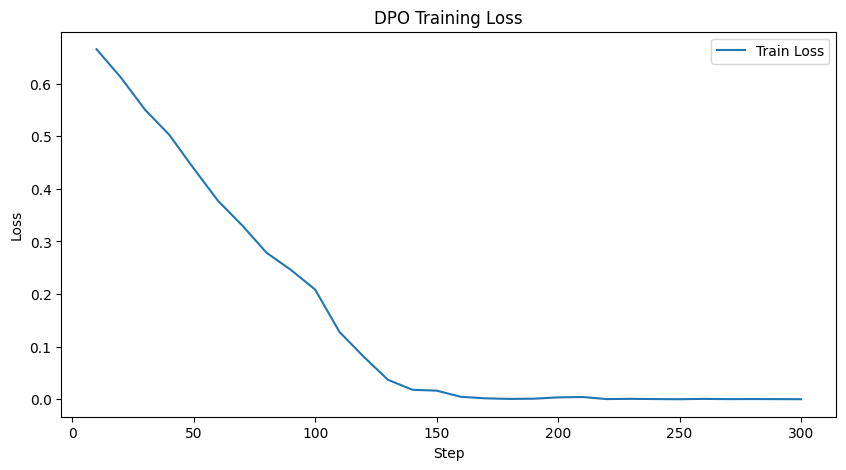

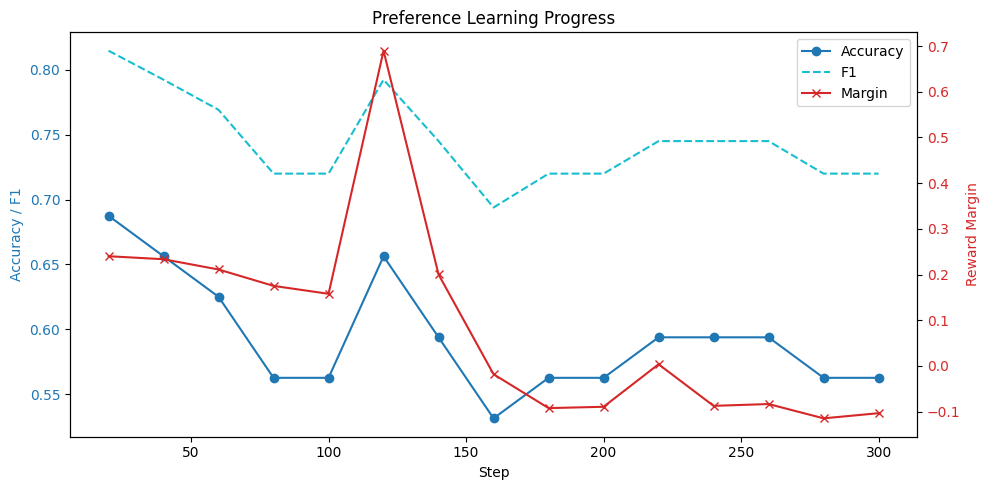

In [13]:
# %%
def plot_local_results(trainer):
    """Parses trainer logs and saves plots to PLOT_DIR."""
    history = pd.DataFrame(trainer.state.log_history)
    
    # 1. Plot Loss
    plt.figure(figsize=(10, 5))
    train_loss = history[history['loss'].notna()]
    plt.plot(train_loss['step'], train_loss['loss'], label='Train Loss')
    plt.title("DPO Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{PLOT_DIR}/loss_curve.png")
    plt.show()

    # 2. Plot Reward Accuracy & Margin
    eval_logs = history[history['eval_accuracy'].notna()]
    if not eval_logs.empty:
        fig, ax1 = plt.subplots(figsize=(10, 5))
        
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Accuracy / F1', color='tab:blue')
        l1, = ax1.plot(eval_logs['step'], eval_logs['eval_accuracy'], label='Accuracy', color='tab:blue', marker='o')
        l2, = ax1.plot(eval_logs['step'], eval_logs['eval_f1'], label='F1', color='tab:cyan', linestyle='--')
        ax1.tick_params(axis='y', labelcolor='tab:blue')

        ax2 = ax1.twinx()
        ax2.set_ylabel('Reward Margin', color='tab:red')
        l3, = ax2.plot(eval_logs['step'], eval_logs['eval_reward_margin'], label='Margin', color='tab:red', marker='x')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        # Combine legends from both axes
        lines = [l1, l2, l3]
        labels = [line.get_label() for line in lines]
        ax1.legend(lines, labels, loc='best')

        plt.title("Preference Learning Progress")
        fig.tight_layout()
        plt.savefig(f"{PLOT_DIR}/metrics_curve.png")
        plt.show()

plot_local_results(trainer)

In [14]:
# Save side-by-side comparison to CSV for local review
comparison_df = pd.DataFrame({
    "Prompt": [eval_dataset[i]["prompt"] for i in range(len(preds))],
    "Target (Human)": [eval_dataset[i]["chosen"] for i in range(len(preds))],
    "Model Output": preds
})
comparison_df.to_csv(f"{BASE_DIR}/generations_comparison.csv", index=False)
print(f"Evaluation complete. Results saved to {BASE_DIR}")

Evaluation complete. Results saved to runs/dpo_distilgpt2


In [34]:
formatted_prompt = f"Question: How are you?\n\nAnswer: "
        
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

# 2. Generation with Diversity Constraints (prevents model collapse)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,      # Crucial to stop loops
        no_repeat_ngram_size=2,       # Prevents phrase stuttering
        pad_token_id=tokenizer.eos_token_id
    )

# 3. Decode and Clean Output
full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
# Extract only the model's generated part (after the prompt)
response = full_text[len(formatted_prompt):].strip()

print(f"{formatted_prompt}{response}")

Question: How are you?

Answer: ____! That's how I always think about that. It was just so surreal when we were growing up in New York, and then there was this guy who had a really good time getting down to the beach). He'd go on those days where he did it all over again - like surfing...that big surfboard
